Saving clientes_streamtico.xlsx to clientes_streamtico (50).xlsx

 ### Exploracion de los datos ###

-----Primeras 5 filas:-----
  id_cliente  edad  meses_activo  quejas     plan gasto_mensual  \
0    CL-1001    41          52.0       2   Básico          5750   
1    CL-1002    35          11.0       1   Básico          4500   
2    CL-1003    30           2.0       0  Basico           4500   
3    CL-1004    44          39.0       2   Básico          5500   
4    CL-1005    29          22.0       2  Premium         11150   

            encuesta_salida cancelo  
0                       NaN      No  
1  Mala atención al cliente      Sí  
2                       NaN      No  
3                       NaN      No  
4                       NaN      No  

-----Información general:-----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306 entries, 0 to 305
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_clie

/tmp/ipykernel_84304/2195288150.py:177: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace({


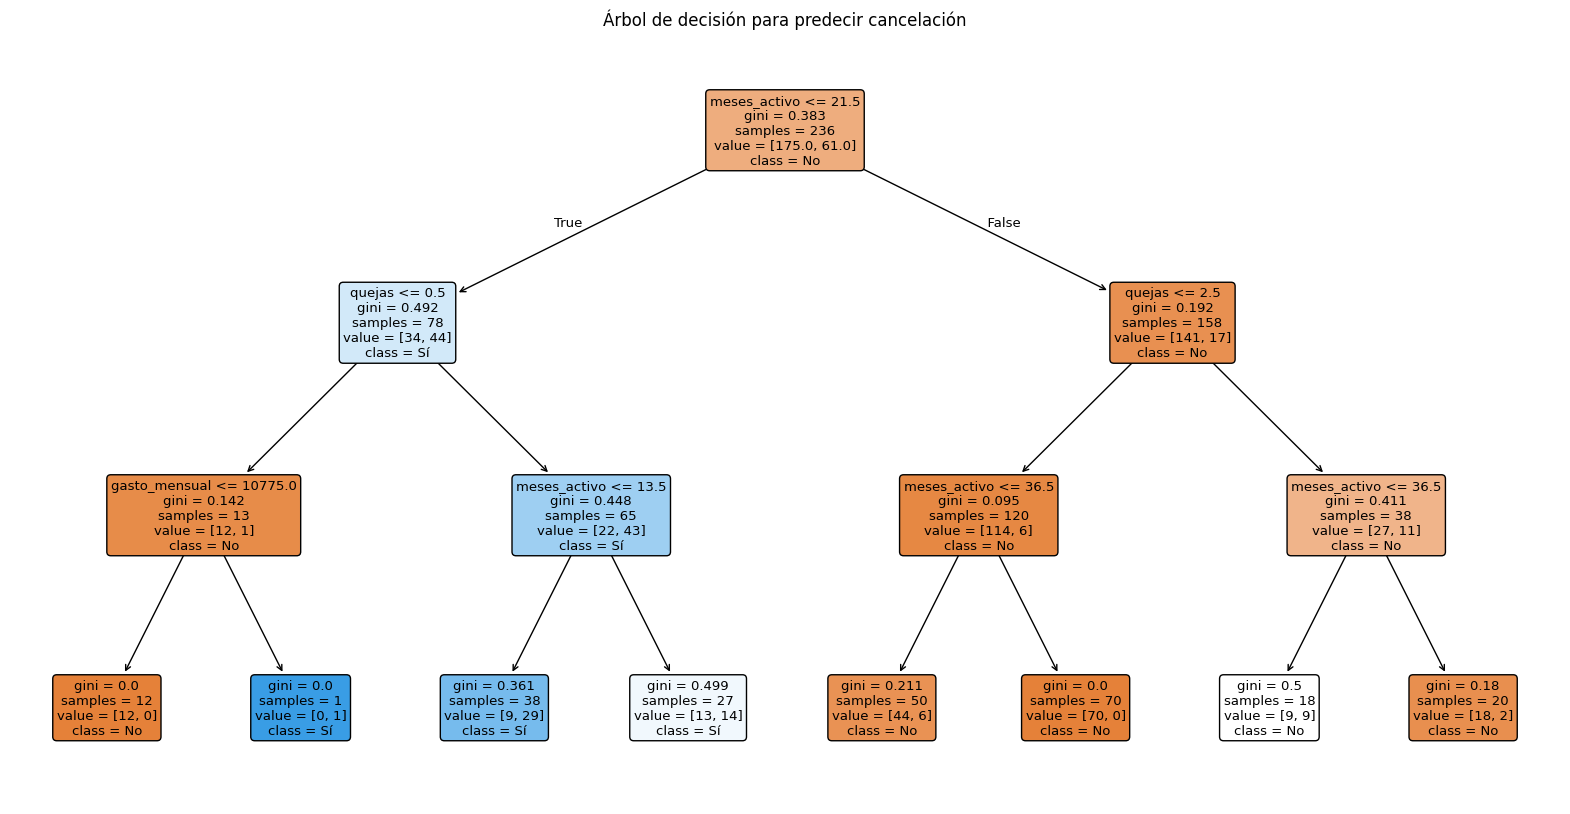

Exactitud del modelo: 0.8166666666666667
Exactitud en porcentaje: 81.67 %
  id_cliente  edad  meses_activo  quejas      plan  gasto_mensual
0      NV-01    24             2       4    Básico           4750
1      NV-02    45            48       0   Premium          10900
2      NV-03    31             6       2  Estándar           7400
3      NV-04    58            30       1  Estándar           7900
4      NV-05    37            12       5    Básico           5250

Prediccion: 
  id_cliente prediccion_cancelo
0      NV-01                 Sí
1      NV-02                 No
2      NV-03                 Sí
3      NV-04                 No
4      NV-05                 Sí


In [ ]:
### Tarea_Cancelacion - Keneth Josue Varela Ruíz ###

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

from google.colab import files

# Subir el archivo
archivo = files.upload()

# Cargar la hoja clientes
df = pd.read_excel("clientes_streamtico.xlsx", sheet_name="clientes")

print("\n ### Exploracion de los datos ###")

# Mostrar las primeras 5 filas
print("\n-----Primeras 5 filas:-----")
print(df.head())

# Mostrar información general de las columnas
print("\n-----Información general:-----")
df.info()

# Contar valores vacíos por columna
print("\n-----Valores vacíos por columna:-----")
print(df.isnull().sum())

# Contar filas completamente duplicadas
print("\n-----Cantidad de filas duplicadas:-----")
print(df.duplicated().sum())

# Mostrar los valores diferentes de plan
print("\n-----Valores de la columna plan:-----")
print(df["plan"].value_counts(dropna=False))

# Mostrar los valores diferentes de cancelo
print("\n-----Valores de la columna cancelo:-----")
print(df["cancelo"].value_counts(dropna=False))

# Mostrar estadísticas de las columnas numéricas
print("\n-----Estadísticas de las columnas numéricas:-----")
print(df.describe())

print("\n-----Edades fuera del rango válido:-----")
print(df[(df["edad"] < 18) | (df["edad"] > 100)][["id_cliente", "edad"]])

print("-----Quejas negativas:-----")
print(df[df["quejas"] < 0][["id_cliente", "quejas"]])

print("\n-----Valores diferentes de plan:-----")
print(df["plan"].unique())
print(df["gasto_mensual"].unique())

print("\n-----Valores vacíos en cancelo:----")
print(df[df["cancelo"].isnull()][["id_cliente", "cancelo"]])

df["cancelo"].value_counts(dropna=False)

print(df.duplicated().sum())
print(df[df.duplicated(keep=False)])

print("\nIDs repetidos:")
print(df[df["id_cliente"].duplicated(keep=False)].sort_values("id_cliente"))

#-------------------------------------------------------------------------------
### Limpieza ###

#Correccion de las edades con valores erroneos
df.loc[df["edad"] == 250, "edad"] = 25
df.loc[df["edad"] == -4, "edad"] = 24
df.loc[df["edad"] == 190, "edad"] = 19

# Reemplazar edad 0 con la mediana de las edades válidas
mediana_edad = df.loc[df["edad"].between(18, 100),"edad"].median()
df.loc[df["edad"] == 0, "edad"] = mediana_edad

# Corrección de valores vacíos y fuera de rango de meses_activo utilizando la mediana
mediana_meses = df.loc[df["meses_activo"].between(1, 60),"meses_activo"].median()

df.loc[(df["meses_activo"].isnull()) |(df["meses_activo"] > 60),"meses_activo"] = mediana_meses


#Corregir valores negativos de quejas
df.loc[df["quejas"] == -2, "quejas"] = 2
df.loc[df["quejas"] == -1, "quejas"] = 1
df.loc[df["quejas"] == -3, "quejas"] = 3


#Estandarizar los nombres de los planes
df["plan"] = (df["plan"].astype(str).str.strip().str.lower())

df["plan"] = df["plan"].replace({
    "basico": "Básico",
    "básico": "Básico",
    "estandar": "Estándar",
    "estándar": "Estándar",
    "premium": "Premium"
})


# Eliminar símbolo de colones y convertir a número.
df["gasto_mensual"] = (df["gasto_mensual"].astype(str).str.replace
 ("₡", "", regex=False).str.replace(",", "", regex=False).astype(float))


#Eliminar valores nulos de cancelo
df = df.dropna(subset=["cancelo"])


#Estandarizar los valores de cancelo
df["cancelo"] = df["cancelo"].str.strip().str.lower()

df["cancelo"] = df["cancelo"].replace({
    "si": "Sí",
    "sí": "Sí",
    "no": "No"
})

#Eliminar filas duplicadas
df = df.drop_duplicates()


#Eliminar Id duplicados
df = df.drop_duplicates(subset="id_cliente",keep="first")

print("\n\nLimpieza completada.")

#-------------------------------------------------------------------------------
print("\n ### Comprobacion de limpieza ###")

print("Cantidad de filas después de la limpieza:")
print(len(df))

print("\nValores vacíos por columna:")
print(df.isnull().sum())

print("\nFilas duplicadas:")
print(df.duplicated().sum())

print("\nIDs repetidos:")
print(df["id_cliente"].duplicated().sum())


df

#-------------------------------------------------------------------------------
print("\n### Machine Learning: ###")
# Variables X
X = df[
    [
        "edad",
        "meses_activo",
        "quejas",
        "plan",
        "gasto_mensual"
    ]
]

# Variable y
y = df["cancelo"]


# Convertir la variable categórica plan a variables numéricas
X = pd.get_dummies(X, columns=["plan"], dtype=int)

print("Variables de X:")
print(X.head())

print("\nVariable de y:")
print(y.head())

# Convertir cancelo a valores numéricos
y = y.replace({
    "No": 0,
    "Sí": 1
})

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

print("Datos de entrenamiento:", len(X_train))
print("Datos de prueba:", len(X_test))

# Entrenar el modelo
modelo = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

modelo.fit(X_train, y_train)

# Dibujar el árbol
plt.figure(figsize=(20, 10))

plot_tree(
    modelo,
    feature_names=X.columns,
    class_names=["No", "Sí"],
    filled=True,
    rounded=True
)

plt.title("Árbol de decisión para predecir cancelación")
plt.show()

#-------------------------------------------------------------------------------
#Prescicion del modelo
y_pred = modelo.predict(X_test)

exactitud = accuracy_score(y_test, y_pred)

print("Exactitud del modelo:", exactitud)
print("Exactitud en porcentaje:", round(exactitud * 100, 2), "%")

#-------------------------------------------------------------------------------

#Probar del modelo con los clientes nuevos
clientes_nuevos = pd.read_excel(
    "clientes_streamtico.xlsx",
    sheet_name="clientes_nuevos"
)

print(clientes_nuevos)

# Seleccionar las mismas variables utilizadas en X
X_nuevos = clientes_nuevos[
    [
        "edad",
        "meses_activo",
        "quejas",
        "plan",
        "gasto_mensual"
    ]
]

# Convertir plan a variables numéricas
X_nuevos = pd.get_dummies(
    X_nuevos,
    columns=["plan"],
    dtype=int
)

# Asegurar que tenga exactamente las mismas columnas que X
X_nuevos = X_nuevos.reindex(
    columns=X.columns,
    fill_value=0
)

# Realizar las predicciones
predicciones = modelo.predict(X_nuevos)

# Convertir 0/1 nuevamente a No/Sí
clientes_nuevos["prediccion_cancelo"] = np.where(
    predicciones == 1,
    "Sí",
    "No"
)

#Mostrar resultados
print("\nPrediccion: ")
print(clientes_nuevos[["id_cliente", "prediccion_cancelo"]])

| N.º de error | Columna afectada | Cómo lo detecté                                                                                                                                                        | Cómo lo corregí                                                                                                                 |
| ------------ | ---------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------- |
| 1            | `edad`           | Revisé los valores mínimos y máximos de la columna y encontré valores fuera del rango válido de 18 a 100 años: `250`, `-4`, `0` y `190`.                               | Corregí los valores inválidos asignándoles valores de edad válidos y la mediana en caso de la edad 0.                                                             |
| 2            | `meses_activo`   | Utilicé `isnull()` y encontré 7 valores faltantes en la columna.                                                                                                       | Reemplacé los valores faltantes utilizando la mediana de los valores válidos de la columna.                                     |
| 3            | `meses_activo`   | Revisé los valores mínimos y máximos y encontré los valores `360`,`480`y`999`, que se salen bastate del rango de 1 a 60 meses.                                                       | Reemplacé los valores `360`,`480`y`999` por la mediana.                                                                                   |
| 4            | `quejas`         | Revisé los valores mínimos y máximos y encontré valores negativos: `-2`, `-1` y `-3`.                                                                                  | Corregí los valores negativos utilizando valores positivos válidos.                                                             |
| 5            | `plan`           | Utilicé `unique()` y `value_counts()` y encontré diferentes formas de escribir los mismos planes, incluyendo diferencias de mayúsculas, minúsculas, espacios y tildes. | Estandaricé todos los nombres para que únicamente quedaran `Básico`, `Estándar` y `Premium`.                                    |
| 6            | `gasto_mensual`  | Revisé los valores de la columna y encontré registros que contenían el símbolo `₡`, además de valores numéricos almacenados como texto.                                | Eliminé el símbolo de moneda y convertí la columna a valores numéricos.                                                         |
| 7            | `cancelo`        | Utilicé `isnull()` y encontré 4 registros sin información en esta columna.                                                                                             | Eliminé los registros que no tenían información en `cancelo`, ya que esta columna es necesaria para el análisis de cancelación. |
| 8            | `cancelo`        | Utilicé `value_counts()` y encontré diferencias en mayúsculas, minúsculas, tildes y espacios, como `Sí`, `sí`, `Si`, `si`, `NO` y `no`.                                | Estandaricé los valores para que únicamente quedaran `Sí` y `No`.                                                               |
| 9            | Filas duplicadas | Utilicé `duplicated()` y encontré 6 filas completamente duplicadas.                                                                                                    | Eliminé las filas completamente duplicadas.                                                                                     |
| 10           | `id_cliente`     | Utilicé `duplicated()` sobre `id_cliente` y encontré identificadores repetidos.                                                                                        | Eliminé los registros duplicados utilizando `id_cliente` como identificador único y conservé la primera aparición.              |


# Definición de variables X e Y
Para el modelo se seleccionaron como variables para X las columnas edad, meses_activo, quejas, plan y gasto_mensual, porque son las características del cliente que pueden ayudar a identificar patrones relacionados con la cancelación del servicio.

La variable para Y es cancelo, porque representa el resultado que se desea predecir: si el cliente canceló o no el servicio.

Se dejó fuera id_cliente porque solo es un identificador y no aporta pata predecir la cancelación. También se excluyó encuesta_salida porque contiene muchos valores vacíos porque esuna encuesta realizada durante el proceso de salida entonces no aporta a la prediccion.

# **Conclusion**
Según el árbol de decisión entrenado, los factores determinantes en la cancelación son meses_activo y el número de quejas acumuladas. Los clientes con pocos meses de antigüedad que presentan varias quejas en el servicio son los más propensos a cancelar. Se le recomienda a StreamTico enfocar sus esfuerzos de retención y atención al cliente prioritario en los usuarios durante sus primeros dos años de suscripción, solucionando ágilmente cualquier queja registrada antes de que decidan abandonar la plataforma.